# Camera calibration with a checkerboard in MuJoCo

This notebook demonstrates the same overall calibration workflow as the Charuco tutorial, but here a classical checkerboard target is used instead of a Charuco board.

The workflow is divided into two main stages:

- **Intrinsic calibration** estimates the camera matrix from multiple checkerboard images captured under different views.
- **Extrinsic calibration** estimates the pose of the camera with respect to the robot base from synchronized robot poses and checkerboard detections.

The example runs in MuJoCo, but the logical steps are the same as in a real setup: prepare the scene, capture diverse images of the calibration target, verify detection quality, compute intrinsics, and finally estimate the robot-to-camera transform.


In [2]:
import numpy as np

import cv2
import glob
import os

import mediapy as media
import matplotlib.pyplot as plt

from IPython.display import clear_output
clear_output()

import mujoco
from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda
from robotblockset.transformations import rot_x, rot_y, rot_z, map_pose, t2x, x2t, frame2world, world2frame, uniqueCartesianPath, xerr, terr
from robotblockset.tools import get_rbs_path
from robotblockset.graphics import display_images

from robotblockset.cameras.collect_calibration_data import create_data_dir, prepare_collect_calibration_data

from robotblockset.cameras.calibration_boards import CheckerBoard
from robotblockset.cameras.camera_calibration import load_images, save_images
from robotblockset.cameras.camera_calibration import load_calibration_data
from robotblockset.cameras.image_converter import ImageConverter

from robotblockset.cameras.mujoco_camera import MujocoCam

np.set_printoptions(precision=3, suppress=True, linewidth=100)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Helper functions for the MuJoCo example

These helper functions save and load images, robot joint configurations, and poses in the format expected by the intrinsic and extrinsic calibration routines.


In [3]:
import json
from robotblockset.cameras.camera_calibration import CameraIntrinsics, save_pose_to_json, load_pose_from_json

import numpy as np
from pathlib import Path


def save_q_to_json(q: np.ndarray, path: str | Path):
    """
    Save robot joint vector q (1D numpy array) to a JSON file.
    """
    q = np.asarray(q, dtype=float).reshape(-1)

    data = {
        "q": q.tolist(),
        "n_joints": int(q.size),
    }

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_q_from_json(path: str | Path) -> np.ndarray:
    """
    Load robot joint vector q from a JSON file and return it as a numpy array.
    """
    path = Path(path)
    data = json.loads(path.read_text(encoding="utf-8"))

    if "q" not in data:
        raise ValueError("JSON does not contain key 'q'")

    q = np.asarray(data["q"], dtype=float)
    return q


def mujoco_save_calibration_sample(sample_index, robot, camera, data_dir):
    ROBOT_STOP_WAIT_TIME = 0.5
    robot.Wait(ROBOT_STOP_WAIT_TIME)

    image_rgb = camera.get_rgb_image_as_int()
    image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format


    suffix = f"{sample_index:04d}"
    image_filename = f"image_{suffix}.png"
    image_filepath = os.path.join(data_dir, image_filename)
    tcp_pose_filename = f"tcp_pose_{suffix}.json"
    tcp_pose_filepath = os.path.join(data_dir, tcp_pose_filename)
    board_pose_filename = f"board_pose_{suffix}.json"
    board_pose_filepath = os.path.join(data_dir, board_pose_filename)
    camera_pose_filename = f"camera_pose_{suffix}.json"
    camera_pose_filepath = os.path.join(data_dir, camera_pose_filename)
    joint_filename = f"joint_{suffix}.json"
    joint_filepath = os.path.join(data_dir, joint_filename)

    cv2.imwrite(image_filepath, image_bgr)

    joints_pos = robot.q_ref
    tcp_pose = robot.GetPose()  # TODO: v katerem task_space
    pose = map_pose(x=tcp_pose, out="T")
    board_pose = robot.GetObjectPose("site", "plate_checker_origin", out="T")
    camera_pose = robot.GetObjectPose('site','cam_frame', out="T")
    save_pose_to_json(tcp_pose_filepath, pose)        
    save_pose_to_json(board_pose_filepath, board_pose)        
    save_pose_to_json(camera_pose_filepath, camera_pose)        
    save_q_to_json(joints_pos, joint_filepath)
    

    return tcp_pose, board_pose, camera_pose, joints_pos, image_bgr

def mujoco_load_calibration_data(data_dir: str):
    intrinsics_path = os.path.join(data_dir, "intrinsics.json")
    with open(intrinsics_path, "r") as f:
        camera_intrinsics = CameraIntrinsics.model_validate_json(f.read())

    resolution = camera_intrinsics.image_resolution.as_tuple()
    intrinsics = camera_intrinsics.as_matrix()

    image_paths = sorted(glob.glob(os.path.join(data_dir, "image_*.png")))
    images = [cv2.imread(image_path) for image_path in image_paths]

    pose_paths = sorted(glob.glob(os.path.join(data_dir, "tcp_pose_*.json")))
    tcp_poses = []
    for filepath in pose_paths:
        pose = load_pose_from_json(filepath)
        tcp_poses.append(pose)

    board_pose_paths = sorted(glob.glob(os.path.join(data_dir, "board_pose_*.json")))
    board_poses = []
    for filepath in board_pose_paths:
        pose = load_pose_from_json(filepath)
        board_poses.append(pose)

    camera_pose_paths = sorted(glob.glob(os.path.join(data_dir, "camera_pose_*.json")))
    camera_poses = []
    for filepath in camera_pose_paths:
        pose = load_pose_from_json(filepath)
        camera_poses.append(pose)

    joint_paths = sorted(glob.glob(os.path.join(data_dir, "joint_*.json")))
    joints_pos = []
    for filepath in joint_paths:
        joints_pos.append(load_q_from_json(filepath))

    return images, tcp_poses, board_poses, camera_poses, joints_pos, intrinsics, resolution

# Initialization

In this section we create the MuJoCo scene, the robot, the simulated camera, the checkerboard target, and the folders used to store calibration data.


## Scene

In [4]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/"
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 0, 0]
scene = mujoco_scene(f"{MODEL_PATH}/calibration_checker_scene.xml", show_camera=None, verbose=2)
# print_body_tree_model(scene.model, "world")

[RBS_DEBUG] [1773380563.934535027] [MuJoCo Scene]: Model loaded successfully.
[RBS_DEBUG] [1773380563.934535027] [MuJoCo Scene]: Viewer started.


## Create robot object

Note: TCP is set to be in the center of the plate and alogned with plate orientation (using sites in model)

In [5]:
r = panda(robot_name="panda", scene=scene)
r.ResetCurrentTarget()
# r.SetTCP(np.eye(4), frame="Flange")
r._default.Kinematics = "Calculated"
print("TCP: \n", r.TCP)

[RBS_INFO] [1773380564.282819510] [panda_PyMuJoCo]: Robot connected to MuJoCo
[RBS_DEBUG] [1773380564.463969707] [MuJoCo Scene]: Viewer launched, running simulation...
TCP: 
 [[-0.     0.707  0.707  0.   ]
 [ 0.     0.707 -0.707  0.   ]
 [-1.    -0.    -0.     0.228]
 [ 0.     0.     0.     1.   ]]


Move the robot to some initial configuration

In [6]:
r.JMove(r.q_home)


0

## Create camera

In [7]:
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
# # K for  (640 x 480)
# intrinsics = np.array([[616.243,   0.   , 321.733],
#        [  0.   , 617.152, 242.248],
#        [  0.   ,   0.   ,   1.   ]])
# # K for (1280 x 960)
# intrinsics = np.array([[1241.521,    0.   ,  643.073],
#        [   0.   , 1239.811,  477.939],
#        [   0.   ,    0.   ,    1.   ]])
# K for (19200 x 108)
intrinsics = np.array([[1396.855,    0.   ,  969.601],
       [   0.   , 1393.465,  543.279],
       [   0.   ,    0.   ,    1.   ]])
# camera = MujocoCam(scene, mujoco_camera_id=0, scene_option=scene_option, intrinsics_matrix=intrinsics)
camera = MujocoCam(scene, mujoco_camera_id=0, resolution=(1920, 1080), scene_option=scene_option, intrinsics_matrix=intrinsics)

Define the position offset of the camera lenses regarding the camera frame.

This offset is useful later when comparing the simulated ground-truth camera pose with the pose recovered by extrinsic calibration.


In [8]:
camera_offset = map_pose(p=[0.002, -0.032, 0], out="T")

## Definition of checker board used for calibration and data folder

CheckerBoard(5x4 inner corners, square=0.04 m, use_sb=True, refine_subpix=True)


""

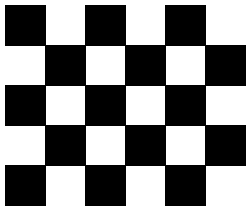

In [10]:
board = CheckerBoard(cols=5, rows=4, square_length_m=0.04, margin_size_m=0.005)
print(board)
media.show_image(board.image())

## Create data folder

In [11]:
img_dir = "mujoco_checkers_calib"
path_img_dir = create_data_dir(img_dir)

[RBS_WARNING] [1773380567.000310898] [robotblockset.cameras.collect_calibration_data]: The data subfolder of mujoco_checkers_calib already exists and is not empty.


## Move camera and define object frame as camera frame

In [12]:
r.SetMocapPose('cam_cam',[1.7, 0, 0.4])
r.Wait(0.5)
pcam = r.GetObjectPose('site','cam_frame')
r.SetObject(pcam)

In [13]:
r.TObject

array([[ 0. , -0. , -1. ,  1.7],
       [ 1. ,  0. , -0. ,  0. ],
       [ 0. , -1. ,  0. ,  0.4],
       [ 0. ,  0. ,  0. ,  1. ]])

In [14]:
pl = r.GetObjectPose('site','plate_checker_origin')
print(r.WorldToObject(pl))

[ 0.06  -0.038  1.384 -0.707 -0.003  0.003 -0.707]


In [15]:
r.SetMocapPose("Target", pl)

In [16]:
r.TCP

array([[-0.   ,  0.707,  0.707,  0.   ],
       [ 0.   ,  0.707, -0.707,  0.   ],
       [-1.   , -0.   , -0.   ,  0.228],
       [ 0.   ,  0.   ,  0.   ,  1.   ]])

# Preliminary checks

Before collecting calibration data, verify that the checkerboard is visible, that the detector finds the pattern reliably, and that the estimated board frame is reasonable.


## Move to pose and check board detection

In [17]:
r.JMove(r.q_home)

0

In [18]:
r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])

0

In [19]:
r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.9, np.random.uniform(-1, 1) * 0.3, np.random.uniform(-1, 1) * 0.9], out="Q"))

0

In [20]:
r.CMoveFor([0.1, 0, 0])

0

In [21]:
r.CMoveFor(rot_z(-np.pi / 8))

0

## Check board frame detection

""

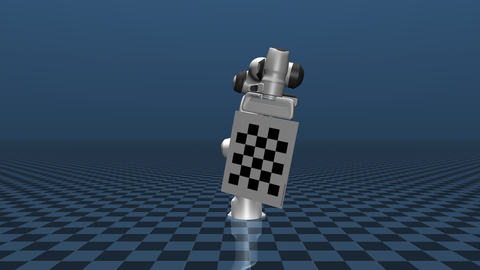

In [22]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
media.show_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

""

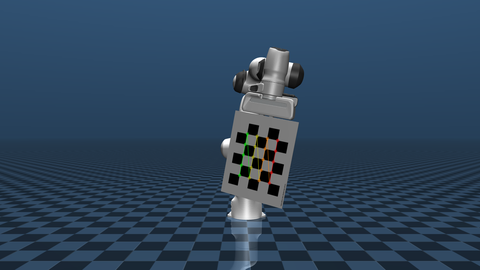

In [23]:
det = board.detect(gray)
img_det = board.drawDetection(image_bgr.copy(), det)
media.show_image(cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

In [24]:
pose = board.detectPose(gray, camera.intrinsics_matrix(), None)
pose.as_pose()

array([0.127, 0.016, 1.263, 0.622, 0.15 , 0.116, 0.759])

In [25]:
pw = r.ObjectToWorld(pose.as_pose())
print(pw)

[ 0.437  0.127  0.384  0.065 -0.674  0.202  0.708]


In [26]:
actual_board_pose = uniqueCartesianPath(r.GetObjectPose("site",'plate_checker_origin'))
print("Actual  board pose in camera frame: ", actual_board_pose)
r.SetMocapPose("Target", actual_board_pose)

Actual  board pose in camera frame:  [ 0.444  0.101  0.379  0.103 -0.663  0.24   0.702]


In [27]:
r.SetMocapPose("Target", pw)

""

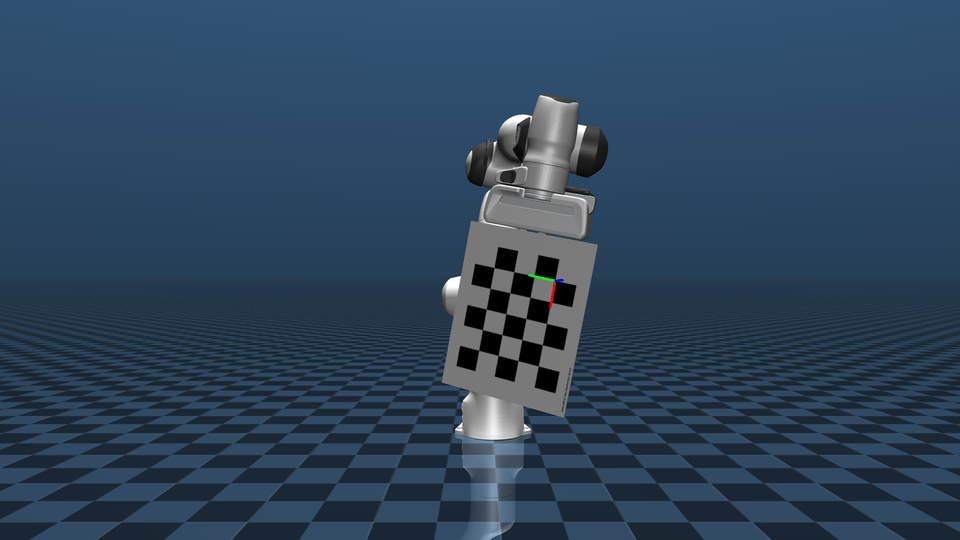

In [28]:
img = board.drawFrame(image_bgr, pose, camera.intrinsics_matrix(), None, length=0.05)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)

# Intrinsic calibration

Intrinsic calibration estimates focal lengths, principal point, and related camera parameters from multiple checkerboard images taken from sufficiently varied poses.


## Motion generation

Selected pose where the plate is in the middle of camera view and oriented approximately to the camera.

This nominal pose is used as the starting point from which random perturbations are generated to collect intrinsic-calibration images.


In [29]:
x0 = np.array([0.4, -0.   ,  0.5 ,  0, -0.71 , 0,  -0.704])
r.JMove(r.q_home)
r.CMove(x0)
q0 = r.q_ref
r.JMove(q0)

0

Execute test motion

In [30]:
images=[]
it=0
for i in range(12):
    # xx = map_pose(p=x0[:3] + np.random.randn(3) * [0.1, 0.2, 0.05], RPY=map_pose(Q=x0[3:], out="RPY") + np.random.randn(3) * 0.4)
    r.JMove(q0)
    r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
    r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.9, np.random.uniform(-1, 1) * 0.3, np.random.uniform(-1, 1) * 0.9], out="Q"))
    r.Wait(0.2)
    image_rgb = camera.get_rgb_image_as_int()
    image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
    images.append(image_bgr)
    print(f"Saved {i+1} sample(s).")


Saved 1 sample(s).
Saved 2 sample(s).
Saved 3 sample(s).
Saved 4 sample(s).
Saved 5 sample(s).
Saved 6 sample(s).
Saved 7 sample(s).
Saved 8 sample(s).
Saved 9 sample(s).
Saved 10 sample(s).
Saved 11 sample(s).
Saved 12 sample(s).


Save imegaes

In [31]:
save_images(img_dir, images)

## Load captured images

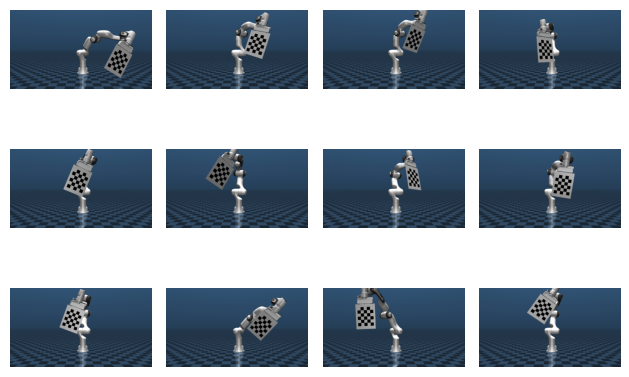

In [32]:
images = load_images(img_dir)
display_images(images, bgr2rgb=True)

media.show_images([frames[i] for i in range(len(frames))], height=240, columns=4)


## Calculate intrinsics

After loading the captured images, solve for the intrinsic parameters of the simulated camera from the detected checkerboard corners.


In [34]:
calib_res = board.intrinsic_calibration(images, silent=True)
print("Matrix:\n", calib_res.to_camera_intrinsics().as_matrix())

Matrix:
 [[1397.622    0.     962.274]
 [   0.    1396.524  540.503]
 [   0.       0.       1.   ]]


Save to JSON file

In [35]:
calib_res.write_intrinsics_json("mujoco",camera.name, out_dir=img_dir)

WindowsPath('mujoco_checkers_calib/mujoco_cam_RGB_intrinsic_calibration.json')

Set camera intrinsics


In [36]:
camera._intrinsics_matrix = calib_res.to_camera_intrinsics().as_matrix()

# Extrinsic calibration

Extrinsic calibration estimates the rigid transform between the robot base and the camera. Each saved sample combines an image with the corresponding robot TCP pose and the simulated board/camera poses.


## Prepare data folder

In [37]:
data_dir = prepare_collect_calibration_data(camera, img_dir)

[RBS_WARNING] [1773380619.979537964] [robotblockset.cameras.collect_calibration_data]: The data subfolder of mujoco_checkers_calib already exists and is not empty.
[RBS_INFO] [1773380619.980538607] [robotblockset.cameras.collect_calibration_data]: Saving calibration data to mujoco_checkers_calib\data


## Move to init pose

In [38]:
x0 = np.array([0.4, -0.   ,  0.5 ,  0, -0.71 , 0,  -0.704])
r.JMove(r.q_home)
r.CMove(x0)
q0 = r.q_ref
r.JMove(q0)

0

## Capture and save random poses and images

Generate a dataset of varied robot poses so the checkerboard appears in many different positions and orientations. This diversity is important for a stable extrinsic estimate.


In [39]:
for sample_index in range(20):
    r.JMove(q0)
    r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
    r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.6, np.random.uniform(-1, 1) * 0.4, np.random.uniform(-1, 1) * 0.6], out="Q"))
    tcp_pose, board_pose, camera_pose, joint_pos, image_bgr = mujoco_save_calibration_sample(sample_index, r, camera, data_dir)  # type: ignore
    print(f"Saved {sample_index+1} sample(s).")

Saved 1 sample(s).
Saved 2 sample(s).
Saved 3 sample(s).
Saved 4 sample(s).
Saved 5 sample(s).
Saved 6 sample(s).
Saved 7 sample(s).
Saved 8 sample(s).
Saved 9 sample(s).
Saved 10 sample(s).
Saved 11 sample(s).
Saved 12 sample(s).
Saved 13 sample(s).
Saved 14 sample(s).
Saved 15 sample(s).
Saved 16 sample(s).
Saved 17 sample(s).
Saved 18 sample(s).
Saved 19 sample(s).
Saved 20 sample(s).


## Load captured images

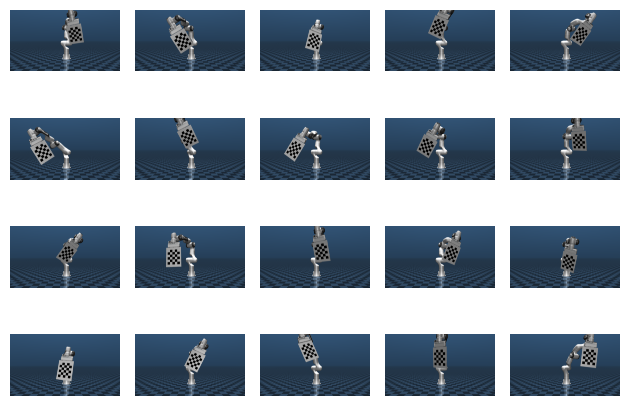

In [40]:
images, tcp_poses, board_poses, camera_poses, joint_poses, intrinsics, resolution = mujoco_load_calibration_data(data_dir)
display_images(images, bgr2rgb=True)

## Check board detection

First inspect one sample in detail, then validate the detector over the full dataset. This helps identify failed detections or systematically weak views before solving the calibration problem.


Select one captured pose

In [41]:
ii = 18
actual_board_T = board_poses[ii]
img = images[ii].copy()
cam_T = camera_poses[ii]
qq = joint_poses[ii]


Move to selected configuration

In [42]:
_ = r.JMove(qq)
r.SetMocapPose("Target", actual_board_T)

Check board detection

Detected board pose in camera frame:  [ 0.039 -0.188  1.178  0.668  0.25   0.159  0.683]
Actual   board pose in camera frame:  [ 0.01  -0.188  1.177  0.668  0.251  0.159  0.682]


""

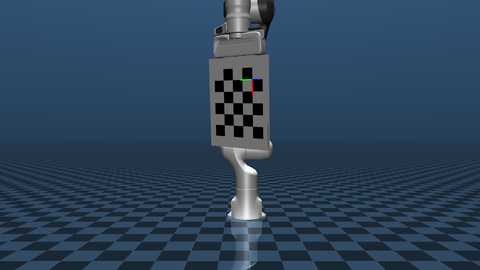

In [43]:
detected_pose = board.detectPose(img, camera.intrinsics_matrix(), None).as_pose()
print("Detected board pose in camera frame: ", detected_pose)
actual_board_pose = uniqueCartesianPath(t2x(actual_board_T))
print("Actual   board pose in camera frame: ", world2frame(actual_board_pose,cam_T))
img_vis = board.drawFrame(img, detected_pose, camera.intrinsics_matrix(), None, length=0.05)
media.show_image(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

In [44]:
r.SetMocapPose("Target", detected_pose)

## Check board detection for all captured poses

Note: Position error is due to offset between camera center and RGBCamera location 

In [45]:
board_poses[ii]

array([[-0.131, -0.552, -0.824,  0.523],
       [ 0.018, -0.832,  0.555,  0.01 ],
       [-0.991,  0.057,  0.119,  0.588],
       [ 0.   ,  0.   ,  0.   ,  1.   ]])

 19:  Board pos in camera frame: [ 0.421 -0.198  1.259  0.664 -0.022  0.006  0.748]  detected: [ 0.448 -0.198  1.26   0.664 -0.022  0.006  0.748]  error: [-0.027  0.    -0.001  0.001  0.    -0.   ]
 18:  Board pos in camera frame: [ 0.01  -0.188  1.177  0.668  0.251  0.159  0.682]  detected: [ 0.039 -0.188  1.178  0.668  0.25   0.159  0.683]  error: [-0.029  0.    -0.001  0.001  0.001 -0.   ]
 17:  Board pos in camera frame: [-0.113 -0.324  1.32   0.813 -0.205 -0.089  0.538]  detected: [-0.083 -0.324  1.321  0.813 -0.205 -0.09   0.538]  error: [-0.031  0.    -0.001 -0.001  0.001 -0.   ]
 16:  Board pos in camera frame: [ 0.139 -0.117  1.345  0.523  0.032  0.057  0.85 ]  detected: [ 0.168 -0.118  1.347  0.523  0.031  0.054  0.85 ]  error: [-0.029  0.001 -0.002 -0.004  0.005  0.001]
 15:  Board pos in camera frame: [ 0.039  0.011  1.28   0.654 -0.008  0.168  0.737]  detected: [ 0.068  0.009  1.281  0.654 -0.008  0.167  0.737]  error: [-0.029  0.002 -0.001 -0.002  0.003 -0.   ]
 14:  Boar

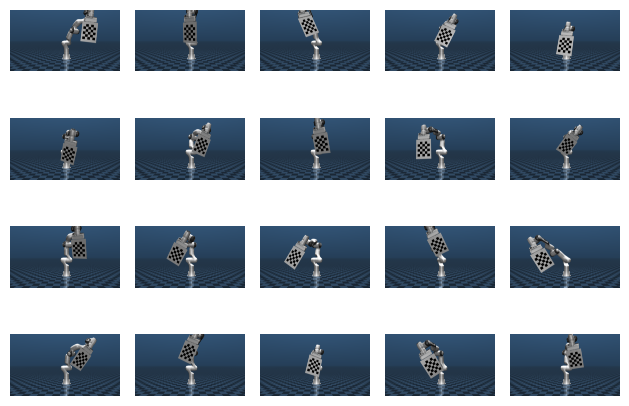

In [46]:
board_images = []
detected_poses = []
for ii in reversed(range(len(images))):
    img = images[ii].copy()
    detected_pose = board.detectPose(img, camera.intrinsics_matrix(), None).as_pose()
    if detected_pose is None:
        images.pop(ii)
        tcp_poses.pop(ii)
        board_poses.pop(ii)
        camera_poses.pop(ii)
    else:
        board_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        actual_board_pose = uniqueCartesianPath(t2x(r.WorldToObject(board_poses[ii])))
        print(f"{ii:3d}:  Board pos in camera frame: {actual_board_pose}  detected: {detected_pose}  error: {xerr(actual_board_pose, detected_pose)}")
        # actual_board_pose = world2frame(board_poses[ii], camera_poses[ii])
        # print(f"{ii}:  Board pos in camera frame: {t2x(board_pose_in_camera_frame)}  detected: {t2x(detected_pose)}")
        detected_poses.append(detected_pose)
display_images(board_images)

## Eye-to-hand calibration

In this setup the camera is fixed with respect to the robot base while the checkerboard is moved by the robot. The calibration therefore follows the eye-to-hand convention.


In [47]:
results_dir = os.path.join(img_dir, f"results")
os.makedirs(results_dir, exist_ok=True)
print(results_dir)

mujoco_checkers_calib\results


In [48]:

images, tcp_poses, intrinsics, resolution = load_calibration_data(img_dir)


In [49]:
gray = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY)
pose = board.detectPose(gray, camera.intrinsics_matrix(), None)
pose.as_pose()

array([ 0.207, -0.18 ,  1.311,  0.759,  0.167, -0.015,  0.629])

In [50]:
poses_dict, errors_dict = board.extrinsic_calibration_all_methods(results_dir, images, tcp_poses, intrinsics, mode="eye_to_hand")
min_error_key = min(errors_dict, key=lambda x: errors_dict.get(x) or float("inf"))
camera_pose_best = poses_dict[min_error_key]


[RBS_INFO] [1773380711.017227411] [robotblockset.cameras.calibration_boards]: Board poses were detected in 20 of the calibration samples.
[RBS_INFO] [1773380711.146793842] [robotblockset.cameras.calibration_boards]: Residual error Tsai: 0.3071
[RBS_INFO] [1773380711.158307552] [robotblockset.cameras.calibration_boards]: Residual error Park: 0.3659
[RBS_INFO] [1773380711.169806242] [robotblockset.cameras.calibration_boards]: Residual error Haraud: 0.3589
[RBS_INFO] [1773380711.182812929] [robotblockset.cameras.calibration_boards]: Residual error Andreff: 0.9382
[RBS_INFO] [1773380711.193817616] [robotblockset.cameras.calibration_boards]: Residual error Daniilidis: 0.5163


Actual and detected camera pose in robot frame

In [51]:
print("Actual camera pose:\n", camera_offset @ x2t(uniqueCartesianPath(r.GetObjectPose("site",'cam_frame'))))
print("Detected camera pose:\n", camera_pose_best)

Actual camera pose:
 [[ 0.    -0.    -1.     1.702]
 [ 1.     0.    -0.    -0.032]
 [ 0.    -1.     0.     0.4  ]
 [ 0.     0.     0.     1.   ]]
Detected camera pose:
 [[ 0.002 -0.    -1.     1.699]
 [ 1.    -0.001  0.002 -0.033]
 [-0.001 -1.     0.     0.399]
 [ 0.     0.     0.     1.   ]]


### Print robot frame in one of images

Camera position in robot frame 

In [52]:
robot_base_in_camera_frame = np.linalg.inv(camera_pose_best)

Select image and draw robot frame in it

""

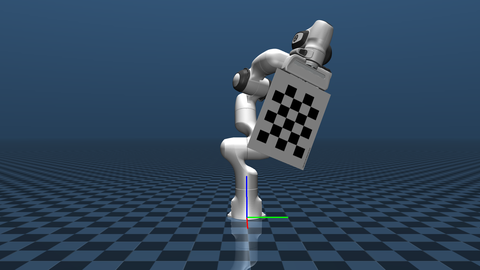

In [53]:
ii = 13
img = images[ii]
img_vis = board.drawFrame(img, robot_base_in_camera_frame, camera.intrinsics_matrix(), None, length=0.2)
media.show_image(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

# Useful relations

After calibration, checkerboard detections in the camera frame can be transformed into the robot frame. The final section illustrates how to use the estimated camera pose in practice.


## Camera position in robot frame 

In [54]:
camera_pose = camera_pose_best
print("Final camera pose:\n", camera_pose)

Final camera pose:
 [[ 0.002 -0.    -1.     1.699]
 [ 1.    -0.001  0.002 -0.033]
 [-0.001 -1.     0.     0.399]
 [ 0.     0.     0.     1.   ]]


Move robot to some configuration

In [55]:
r.JMove(q0)


0

In [56]:
r.CMoveFor([0.1, 0, 0])

0

In [57]:
r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
r.CMoveFor(map_pose(RPY=[np.random.randn(1) * 0.7, np.random.randn(1) * 0.3, np.random.randn(1) * 0.7], out="Q"))
r.Wait(0.2)

Detect board

""

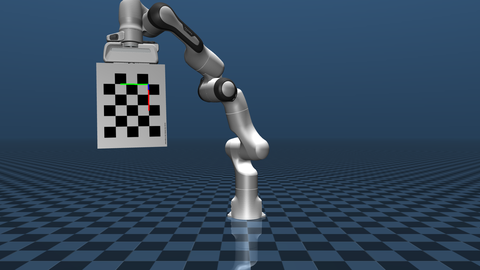

In [58]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
board_T = board.detectPose(image_bgr, intrinsics).as_homogeneous_matrix()
img = board.drawFrame(image_bgr,board_T, intrinsics)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Position of board in robot frame

In [59]:
board_T_robot = frame2world(board_T, camera_pose)
print("Detected board pose in robot frame: ", t2x(board_T_robot))

actual_board_pose = uniqueCartesianPath(r.GetObjectPose("site",'plate_checker_origin'))
print("Actual   board pose in robot frame: ", actual_board_pose)

Detected board pose in robot frame:  [ 0.367 -0.382  0.594  0.076  0.724  0.098 -0.679]
Actual   board pose in robot frame:  [ 0.369 -0.384  0.593  0.078  0.724  0.101 -0.678]


In [60]:
r.SetMocapPose("Target", actual_board_pose)

In [ ]:
r.SetMocapPose("Target", board_T_robot)

: 